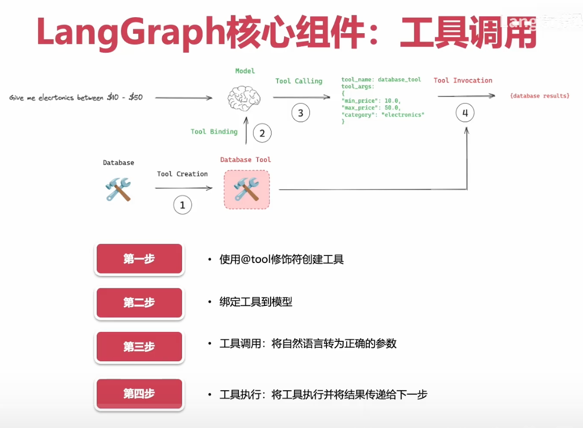

In [7]:
from langchain_core.messages import AIMessage
from langchain_core.tools import tool
from langgraph.prebuilt import ToolNode

@tool
def get_weather(location: str)->str:
    '''
    根据location来获取天气
    :param location:
    :return:
    '''
    if location.lower() in ["beijing","shanghai"]:
        return "现在温度20,晴天"
    else:
        return "现在温度10度"

@tool
def get_coolest_cities() ->list:
    '''
    获取最冷天气列表
    :return:
    '''
    return ["haerbing","beijing"]


tools = [get_weather,get_coolest_cities]
tool_node = ToolNode(tools)


print(type(tool_node))
print(tool_node)

<class 'langgraph.prebuilt.tool_node.ToolNode'>
tools(tags=None, recurse=True, explode_args=False, func_accepts={'config': ('N/A', <class 'inspect._empty'>), 'runtime': ('N/A', <class 'inspect._empty'>)}, _tools_by_name={'get_weather': StructuredTool(name='get_weather', description='根据location来获取天气\n:param location:\n:return:', args_schema=<class 'langchain_core.utils.pydantic.get_weather'>, func=<function get_weather at 0x14468c040>), 'get_coolest_cities': StructuredTool(name='get_coolest_cities', description='获取最冷天气列表\n:return:', args_schema=<class 'langchain_core.utils.pydantic.get_coolest_cities'>, func=<function get_coolest_cities at 0x103c028e0>)}, _injected_args={'get_weather': _InjectedArgs(state={}, store=None, runtime=None), 'get_coolest_cities': _InjectedArgs(state={}, store=None, runtime=None)}, _handle_tool_errors=<function _default_handle_tool_errors at 0x141b95da0>, _messages_key='messages', _wrap_tool_call=None, _awrap_tool_call=None)


In [8]:
from langgraph.runtime import DEFAULT_RUNTIME

message_with_single_tool_call = AIMessage(
    content="",
    tool_calls=[
        {
            "name":"get_weather",
            "args":{"location":"beijing"},
            "id":"tool_call_1",
            "type":"tool_call"
        }
    ]
)

res = tool_node.invoke(
    {
        "messages":[message_with_single_tool_call]
    },
    runtime=DEFAULT_RUNTIME)

print(res)


{'messages': [ToolMessage(content='现在温度20,晴天', name='get_weather', tool_call_id='tool_call_1')]}


## 绑定工具

In [9]:
from model_factory import MiniMax_Model

# 给模型绑定工具
model = MiniMax_Model.bind_tools(tools)

res = model.invoke("what is the weather in beijing").tool_calls
print(res)

[{'name': 'get_weather', 'args': {'location': 'beijing'}, 'id': '019dd9de41aeffab4b0226235998c1cf', 'type': 'tool_call'}]


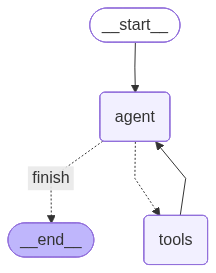

In [21]:
from langgraph.graph import  StateGraph,START,END,MessagesState
from IPython.display import  Image,display

def should_continue(state:MessagesState):
    last_messages = state["messages"][-1]
    if last_messages.tool_calls:
        return "tools"
    else:
        return "finish"

def call_model(state:MessagesState) ->dict:
    messages = state["messages"]
    res = model.invoke(messages)
    return {"messages":[res]}

graph = (
    StateGraph(MessagesState).add_node("agent",call_model)
    .add_node("tools",tool_node)
    .add_edge(START,"agent")
    .add_edge("tools","agent").add_conditional_edges(
        "agent",
         should_continue,
        {
            "tools":"tools",
            "finish":END
        }
    ).compile()
)

display(Image(graph.get_graph().draw_mermaid_png()))

In [23]:
input = {
    "messages":[
        {"role":"user","content":"what is the weather in beijing"}
    ]
}

res = graph.stream(input,stream_mode="values")
for item in res:
    item["messages"][-1].pretty_print()

================================ Human Message =================================

what is the weather in beijing
================================== Ai Message ==================================
Tool Calls:
  get_weather (019dd9eb15e6ea01e9511b72a4cd55f8)
 Call ID: 019dd9eb15e6ea01e9511b72a4cd55f8
  Args:
    location: beijing
================================= Tool Message =================================
Name: get_weather

现在温度20,晴天
================================== Ai Message ==================================



The current weather in Beijing is sunny with a temperature of 20°C. It looks like pleasant weather for outdoor activities! 

If you need more detailed information or want to know the forecast, feel free to ask!


In [25]:
for chunk in graph.stream(input={"messages":[
    {"role":"user","content":"what is the coldest city? and the temperature here"}
]},stream_mode="values"):
    chunk["messages"][-1].pretty_print()

================================ Human Message =================================

what is the coldest city? and the temperature here
================================== Ai Message ==================================
Tool Calls:
  get_coolest_cities (019dd9f02bcaa8f62c527e023106f89e)
 Call ID: 019dd9f02bcaa8f62c527e023106f89e
  Args:
================================= Tool Message =================================
Name: get_coolest_cities

["haerbing", "beijing"]
================================== Ai Message ==================================
Tool Calls:
  get_weather (019dd9f035858a51920f5e19268259cd)
 Call ID: 019dd9f035858a51920f5e19268259cd
  Args:
    location: haerbing
================================= Tool Message =================================
Name: get_weather

现在温度10度
================================== Ai Message ==================================



The coldest city in the list is **Harbin** (Haerbing).  
Its current temperature is **10 °C** (about 50 °F).  

(Beijing is also